# Collateral analysis — if I unlearn malignant biology, what happens to benign biology?

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

MODE = 'content'                                   # '' = old {tag}.json ; 'content' = new masked run
suffix = f'.{MODE}' if MODE else ''
RESULTS = Path('.').resolve().parent / 'run_results/routing_single/Qwen3-30B-A3B'
HAZ, BEN = 'wmdp_bio', 'mmlu_college_biology'
LAB = {HAZ: 'hazardous bio', BEN: 'benign bio'}

data = {t: json.load(open(RESULTS / f'{t}{suffix}.json')) for t in [HAZ, BEN]}
ap = {t: np.array(d['applied_weight']) for t, d in data.items()}   # [L,E] impact
fr = {t: np.array(d['freq'])           for t, d in data.items()}   # [L,E] activation
L, E = ap[HAZ].shape
k = data[HAZ]['top_k']
print(f'layers={L}  experts={E}  top_k={k}  files={"{tag}"+suffix+".json"}')
for t in (HAZ, BEN):
    print(f"  {LAB[t]:14s} {data[t]['n_prompts']:4d} prompts | route_tokens={data[t].get('route_tokens','(old: all tokens)')}")

layers=48  experts=128  top_k=8  files={tag}.content.json
  hazardous bio   160 prompts | route_tokens=content
  benign bio      160 prompts | route_tokens=content


## 0. Verify the meeting numbers

In [2]:
kk = k
topk = lambda M, l: np.argsort(M[l])[::-1][:kk]
eff  = lambda f: np.exp(-(f*np.log(f+1e-12)).sum(1))   # effective # experts / layer

# Bullet 2 — diffuse routing (~52 of 128 each)
print(f'Bullet 2  effective experts/layer:  hazardous {eff(fr[HAZ]).mean():.0f}   benign {eff(fr[BEN]).mean():.0f}')

# Bullet 1 — entanglement alignment (~0.84)
ex = np.array([ap[BEN][l][topk(ap[HAZ],l)].sum() for l in range(L)])
se = np.array([ap[BEN][l][topk(ap[BEN],l)].sum() for l in range(L)])
al = ex/se
print(f'Bullet 1  mean alignment (entanglement): {al.mean():.2f}')

# Bullet 3 — no separation at any granularity
print(f'Bullet 3a layers with alignment >= 0.70: {int((al>=0.70).sum())} of {L}')
lb = int(al.argmin()); H, B = set(topk(ap[HAZ],lb).tolist()), set(topk(ap[BEN],lb).tolist())
print(f'Bullet 3b least-entangled layer {lb}: {len(H&B)}/{kk} top experts still shared')
la = int(np.argmax([ap[HAZ][x].max() for x in range(L)])); ue = int(ap[HAZ][la].argmax())
print(f'Bullet 3c UOE target L{la}/e{ue}: hazardous {ap[HAZ][la][ue]:.3f}, benign {ap[BEN][la][ue]:.3f} '
      f'({ap[BEN][la][ue]/ap[HAZ][la][ue]:.0%} as much)')

Bullet 2  effective experts/layer:  hazardous 52   benign 52
Bullet 1  mean alignment (entanglement): 0.84
Bullet 3a layers with alignment >= 0.70: 44 of 48
Bullet 3b least-entangled layer 23: 4/8 top experts still shared
Bullet 3c UOE target L34/e69: hazardous 0.178, benign 0.101 (57% as much)


## 0.4 Individual spread, then overlap


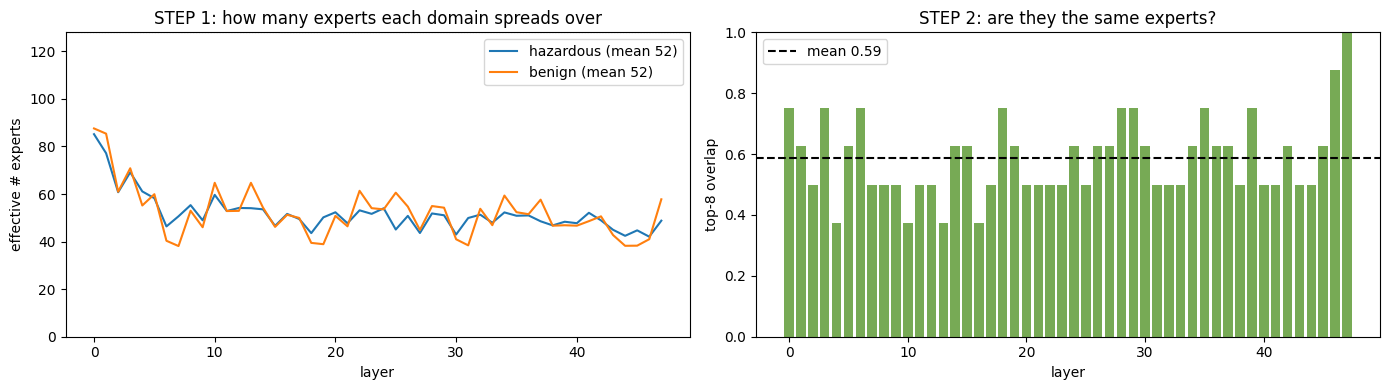

STEP 1  individual spread : hazardous 52,  benign 52  effective experts/layer
STEP 2  same experts?     : top-8 overlap 0.59   (1=identical sets, 0=disjoint)


In [3]:
# STEP 1 - individual spread (each domain's own routing)
eff = lambda f: np.exp(-(f*np.log(f+1e-12)).sum(1))
effH, effB = eff(fr[HAZ]), eff(fr[BEN])

# STEP 2 - overlap (are those experts the same?)
tset = lambda M, l: set(np.argsort(M[l])[::-1][:k].tolist())
overlap = np.array([len(tset(ap[HAZ],l) & tset(ap[BEN],l))/k for l in range(L)])

fig, axx = plt.subplots(1, 2, figsize=(14,4))
axx[0].plot(effH, label=f'hazardous (mean {effH.mean():.0f})')
axx[0].plot(effB, label=f'benign (mean {effB.mean():.0f})')
axx[0].axhline(E, ls=':', c='grey', lw=.8)
axx[0].set_xlabel('layer'); axx[0].set_ylabel('effective # experts'); axx[0].set_ylim(0, E)
axx[0].set_title('STEP 1: how many experts each domain spreads over'); axx[0].legend()
axx[1].bar(range(L), overlap, color='#77aa55')
axx[1].axhline(overlap.mean(), ls='--', c='k', label=f'mean {overlap.mean():.2f}')
axx[1].set_xlabel('layer'); axx[1].set_ylabel(f'top-{k} overlap'); axx[1].set_ylim(0,1)
axx[1].set_title('STEP 2: are they the same experts?'); axx[1].legend()
plt.tight_layout(); plt.show()

print(f'STEP 1  individual spread : hazardous {effH.mean():.0f},  benign {effB.mean():.0f}  effective experts/layer')
print(f'STEP 2  same experts?     : top-{k} overlap {overlap.mean():.2f}   (1=identical sets, 0=disjoint)')

### Per-layer effective experts

The effective-expert count at *each* layer (the mean ~52 broken out). Early layers are very diffuse; from layer ~4 on it settles to ~45–55, and never drops below ~40 — biology is never funneled into a handful of experts.

In [4]:
import pandas as pd
efff = lambda f: np.exp(-(f*np.log(f+1e-12)).sum(1))
eH, eB = efff(fr[HAZ]), efff(fr[BEN])
print(f'mean : hazardous {eH.mean():.1f}   benign {eB.mean():.1f}   (of {E})')
print(f'floor: hazardous {eH.min():.1f} (L{eH.argmin()})   benign {eB.min():.1f} (L{eB.argmin()})')
eff_tbl = pd.DataFrame({'layer': range(L),
                        'hazardous_eff_experts': eH.round(1),
                        'benign_eff_experts': eB.round(1)})
eff_tbl

mean : hazardous 51.9   benign 52.2   (of 128)
floor: hazardous 42.1 (L46)   benign 38.1 (L7)


,layer,hazardous_eff_experts,benign_eff_experts
0,0,85.2,87.6
1,1,77.2,85.4
2,2,60.8,61.0
3,3,69.1,70.8
4,4,61.1,55.2
5,5,58.3,59.9
6,6,46.4,40.3
7,7,50.6,38.1
8,8,55.3,53.0
9,9,49.0,46.0


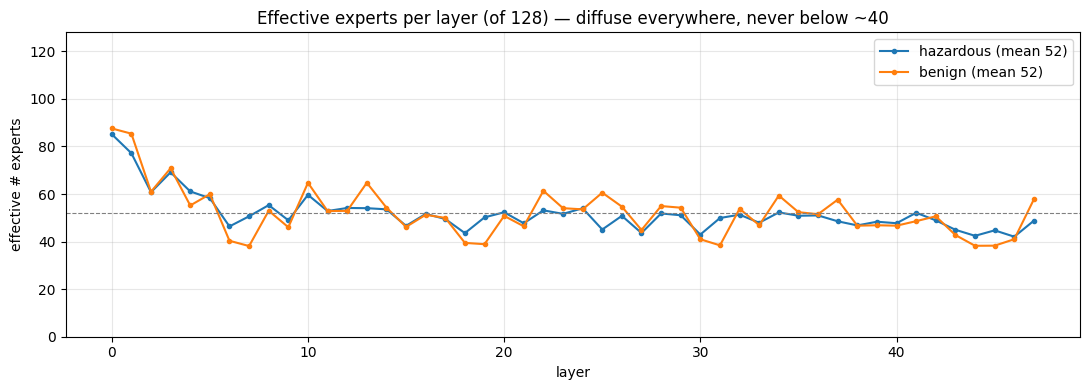

In [ ]:
# Per-layer effective experts — line plot
_eff = lambda f: np.exp(-(f*np.log(f+1e-12)).sum(1))
eH, eB = _eff(fr[HAZ]), _eff(fr[BEN])
plt.figure(figsize=(11,4))
plt.plot(eH, marker='.', label=f'hazardous (mean {eH.mean():.0f})')
plt.plot(eB, marker='.', label=f'benign (mean {eB.mean():.0f})')
plt.axhline(eH.mean(), ls='--', c='grey', lw=.8)
plt.ylim(0, E)
plt.xlabel('layer'); plt.ylabel('effective # experts')
plt.title(f'Effective experts per layer')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 0.5 Slide figures

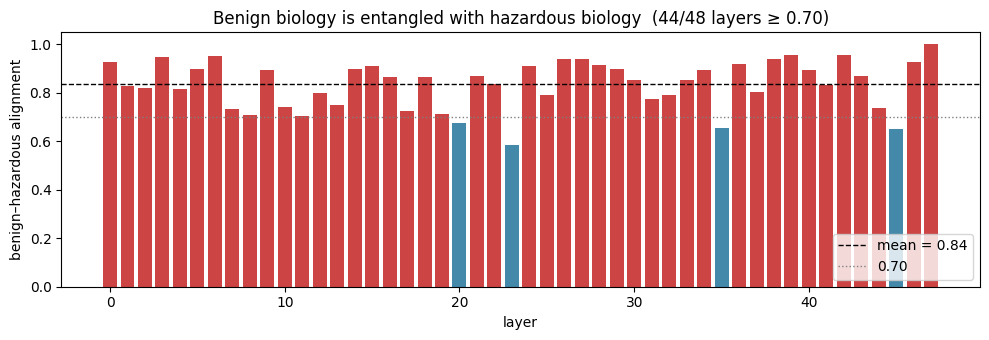

In [6]:
# Figure A — entanglement per layer
topk = lambda M, l: np.argsort(M[l])[::-1][:k]
ex = np.array([ap[BEN][l][topk(ap[HAZ],l)].sum() for l in range(L)])
se = np.array([ap[BEN][l][topk(ap[BEN],l)].sum() for l in range(L)])
al = ex/se
plt.figure(figsize=(10,3.5))
plt.bar(range(L), al, color=['#cc4444' if a>=0.70 else '#4488aa' for a in al])
plt.axhline(al.mean(), ls='--', c='k', lw=1, label=f'mean = {al.mean():.2f}')
plt.axhline(0.70, ls=':', c='grey', lw=1, label='0.70')
plt.ylim(0,1.05); plt.xlabel('layer'); plt.ylabel('benign–hazardous alignment')
plt.title(f'Benign biology is entangled with hazardous biology  '
          f'({int((al>=0.70).sum())}/{L} layers ≥ 0.70)')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

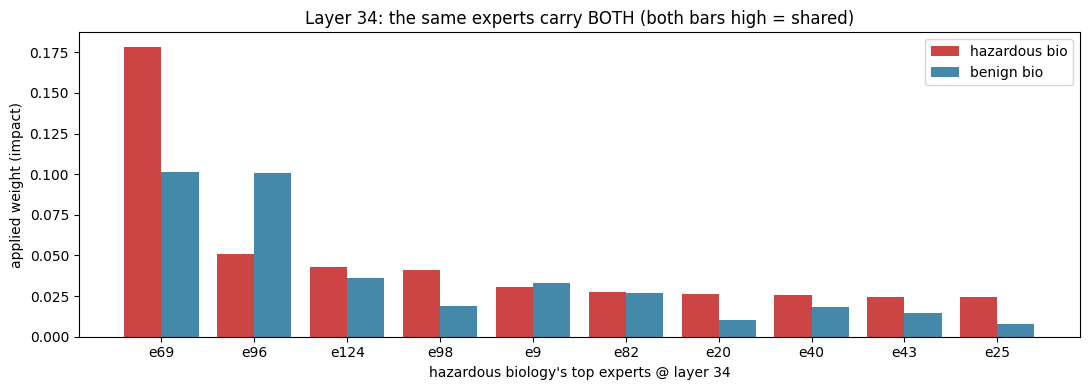

In [7]:
# Figure B — same experts carry both (pick any layer; 34 = UOE-target layer)
def expert_bars(l, top=10):
    order = np.argsort(ap[HAZ][l])[::-1][:top]
    x = np.arange(len(order)); w = 0.4
    plt.figure(figsize=(11,4))
    plt.bar(x-w/2, [ap[HAZ][l][e] for e in order], w, label='hazardous bio', color='#cc4444')
    plt.bar(x+w/2, [ap[BEN][l][e] for e in order], w, label='benign bio',    color='#4488aa')
    plt.xticks(x, [f'e{e}' for e in order]); plt.ylabel('applied weight (impact)')
    plt.xlabel(f"hazardous biology's top experts @ layer {l}")
    plt.title(f'Layer {l}: the same experts carry BOTH (both bars high = shared)')
    plt.legend(); plt.tight_layout(); plt.show()

expert_bars(34)

## 1. Collateral overview — is benign bio entangled with hazardous bio?

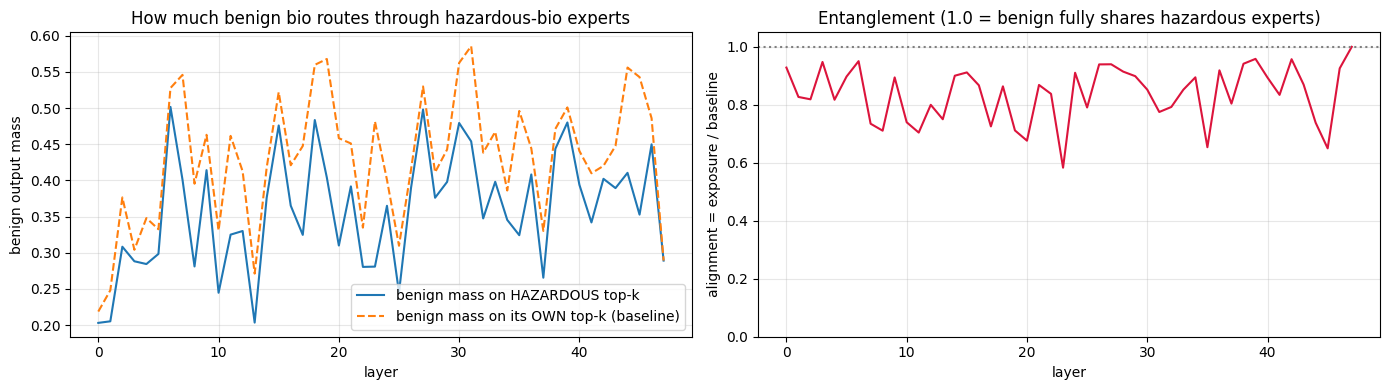

mean alignment = 0.84  -> benign concentrates ~84% as much on hazardous experts as on its own (high = hard to unlearn without collateral)

layers with LOWEST entanglement (benign most separable -> least collateral if you intervene there):
  layer 23: alignment=0.58  exposure=0.28  top8_overlap=0.50
  layer 45: alignment=0.65  exposure=0.35  top8_overlap=0.62
  layer 35: alignment=0.65  exposure=0.32  top8_overlap=0.75
  layer 20: alignment=0.68  exposure=0.31  top8_overlap=0.50
  layer 11: alignment=0.70  exposure=0.33  top8_overlap=0.50
  layer  8: alignment=0.71  exposure=0.28  top8_overlap=0.50


In [8]:
def topk(M, l, kk=k): return np.argsort(M[l])[::-1][:kk]

overlap = np.array([len(set(topk(ap[HAZ],l).tolist()) & set(topk(ap[BEN],l).tolist()))/k for l in range(L)])
expo    = np.array([ap[BEN][l][topk(ap[HAZ],l)].sum() for l in range(L)])   # benign mass on HAZARDOUS top-k
benself = np.array([ap[BEN][l][topk(ap[BEN],l)].sum() for l in range(L)])   # benign mass on OWN top-k
align   = expo / benself

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(expo, label='benign mass on HAZARDOUS top-k')
ax[0].plot(benself, '--', label='benign mass on its OWN top-k (baseline)')
ax[0].set_xlabel('layer'); ax[0].set_ylabel('benign output mass'); ax[0].legend()
ax[0].set_title('How much benign bio routes through hazardous-bio experts'); ax[0].grid(alpha=.3)
ax[1].plot(align, color='crimson'); ax[1].axhline(1, ls=':', c='grey')
ax[1].set_xlabel('layer'); ax[1].set_ylabel('alignment = exposure / baseline'); ax[1].set_ylim(0, 1.05)
ax[1].set_title('Entanglement (1.0 = benign fully shares hazardous experts)'); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'mean alignment = {align.mean():.2f}  -> benign concentrates ~{align.mean():.0%} as much on '
      f'hazardous experts as on its own (high = hard to unlearn without collateral)')
print('\nlayers with LOWEST entanglement (benign most separable -> least collateral if you intervene there):')
for l in np.argsort(align)[:6]:
    print(f'  layer {l:2d}: alignment={align[l]:.2f}  exposure={expo[l]:.2f}  top{k}_overlap={overlap[l]:.2f}')

## 2. Inspect one layer — which experts are shared vs exclusive

`show_layer(l)` splits the top experts into SHARED (interference happens here), HAZARDOUS-only (could target with less benign cost), and BENIGN-only (what you'd want to protect).

In [9]:
def show_layer(l, top=10):
    H, B = topk(ap[HAZ], l, top), topk(ap[BEN], l, top)
    Hs, Bs = set(H.tolist()), set(B.tolist())
    print(f'layer {l} | top-{top} experts by applied_weight (impact)')
    print(' SHARED (both rely on -> unlearning hits benign here):')
    for e in sorted(Hs & Bs):
        print(f'   expert {e:3d}:  hazardous={ap[HAZ][l][e]:.3f}   benign={ap[BEN][l][e]:.3f}')
    print(' HAZARDOUS-only (high hazardous, low benign):')
    for e in [x for x in H if x not in Bs]:
        print(f'   expert {e:3d}:  hazardous={ap[HAZ][l][e]:.3f}   benign={ap[BEN][l][e]:.3f}')
    print(' BENIGN-only (protect these):')
    for e in [x for x in B if x not in Hs]:
        print(f'   expert {e:3d}:  benign={ap[BEN][l][e]:.3f}   hazardous={ap[HAZ][l][e]:.3f}')
    print(f' -> benign mass on hazardous top-{top}: {ap[BEN][l][topk(ap[HAZ],l,top)].sum():.2f}')

show_layer(30)

layer 30 | top-10 experts by applied_weight (impact)
 SHARED (both rely on -> unlearning hits benign here):
   expert  33:  hazardous=0.057   benign=0.035
   expert  49:  hazardous=0.107   benign=0.162
   expert  82:  hazardous=0.096   benign=0.039
   expert  92:  hazardous=0.046   benign=0.088
   expert 118:  hazardous=0.029   benign=0.025
   expert 121:  hazardous=0.150   benign=0.120
   expert 123:  hazardous=0.021   benign=0.042
 HAZARDOUS-only (high hazardous, low benign):
   expert 114:  hazardous=0.033   benign=0.005
   expert 100:  hazardous=0.026   benign=0.005
   expert  34:  hazardous=0.023   benign=0.018
 BENIGN-only (protect these):
   expert  84:  benign=0.048   hazardous=0.020
   expert  24:  benign=0.029   hazardous=0.000
   expert 103:  benign=0.025   hazardous=0.015
 -> benign mass on hazardous top-10: 0.54


## 3. Difference map — hazardous-preferred vs benign-preferred experts

Red = experts hazardous bio weights more than benign (candidate targets, lower benign cost). Blue = benign-preferred (protect). Mostly-white = shared / no separation.

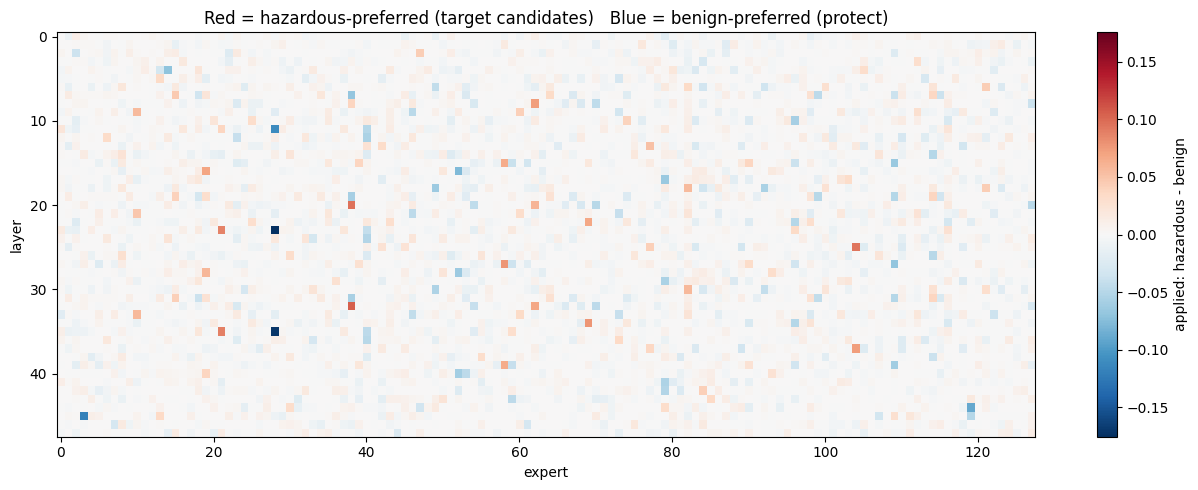

most HAZARDOUS-exclusive (layer, expert) -- highest hazardous, lowest benign:
  L32 e 38  hazardous=0.157  benign=0.052  Δ=+0.105
  L20 e 38  hazardous=0.150  benign=0.054  Δ=+0.096
  L25 e104  hazardous=0.172  benign=0.079  Δ=+0.094
  L35 e 21  hazardous=0.130  benign=0.041  Δ=+0.089
  L23 e 21  hazardous=0.128  benign=0.041  Δ=+0.087
  L27 e 58  hazardous=0.095  benign=0.017  Δ=+0.078
  L34 e 69  hazardous=0.178  benign=0.101  Δ=+0.077
  L 8 e 62  hazardous=0.096  benign=0.022  Δ=+0.073
  L37 e104  hazardous=0.147  benign=0.073  Δ=+0.073
  L16 e 19  hazardous=0.090  benign=0.020  Δ=+0.069
  L32 e 62  hazardous=0.088  benign=0.020  Δ=+0.068
  L22 e 69  hazardous=0.116  benign=0.049  Δ=+0.068


In [10]:
diff = ap[HAZ] - ap[BEN]
vmax = np.abs(diff).max()
plt.figure(figsize=(13, 5))
plt.imshow(diff, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
plt.colorbar(label='applied: hazardous - benign')
plt.xlabel('expert'); plt.ylabel('layer')
plt.title('Red = hazardous-preferred (target candidates)   Blue = benign-preferred (protect)')
plt.tight_layout(); plt.show()

print('most HAZARDOUS-exclusive (layer, expert) -- highest hazardous, lowest benign:')
for idx in np.argsort(diff.ravel())[::-1][:12]:
    l, e = divmod(idx, E)
    print(f'  L{l:2d} e{e:3d}  hazardous={ap[HAZ][l][e]:.3f}  benign={ap[BEN][l][e]:.3f}  Δ=+{diff[l,e]:.3f}')

## 4. Layer ranking — where could you intervene with least benign collateral

Sorted by alignment (low = benign least entangled with hazardous at that layer). Combine with the LUNAR (s1-s2) layer selection; these are the layers where the collateral cost is structurally lowest.

In [11]:
import pandas as pd
tbl = pd.DataFrame({
    'layer': range(L),
    'benign_exposure': expo.round(3),
    'benign_self': benself.round(3),
    'alignment': align.round(2),
    f'top{k}_overlap': overlap.round(2),
}).sort_values('alignment').reset_index(drop=True)
tbl.head(15)

,layer,benign_exposure,benign_self,alignment,top8_overlap
0,23,0.281,0.482,0.58,0.50
1,35,0.324,0.496,0.65,0.75
2,45,0.353,0.543,0.65,0.62
3,20,0.310,0.458,0.68,0.50
4,11,0.325,0.462,0.70,0.50
5,8,0.281,0.395,0.71,0.50
6,19,0.404,0.568,0.71,0.62
7,7,0.401,0.546,0.73,0.50
8,17,0.325,0.448,0.73,0.50
9,44,0.411,0.556,0.74,0.50


## Caveats (read before believing any single layer)

1. **Old all-token runs** (`MODE=''`): chat template + `<think>` block are counted, inflating shared routing. Re-run with `MODE='content'`.
2. **MCQ asymmetry**: benign bio still has inline options, hazardous does not. Benign may route some mass to MCQ-format experts hazardous lacks, which would *deflate* exposure — so the true entanglement could be **higher** than shown.
3. **No noise floor**: at 160 prompts, small per-layer differences may be sampling noise. Run the split-half (same dataset, two halves) and trust only layer differences that exceed it.
4. **Routing entanglement ≠ post-unlearning damage.** This shows where the experts overlap; the actual benign damage also depends on LUNAR's retain-preserving training. High entanglement means that training is doing real work, not that benign is doomed.